In [2]:
import pandas as pd
train = pd.read_csv(r"C:\Users\mpkhd\Desktop\Uni\4th year\Sem1\ST4052\Project1\Advanced\train.csv")
test = pd.read_csv(r"C:\Users\mpkhd\Desktop\Uni\4th year\Sem1\ST4052\Project1\Advanced\test.csv")

In [5]:
X = train.drop(columns = 'HiringDecision')
y = train['HiringDecision']

In [8]:
from sklearn import linear_model

logr = linear_model.LogisticRegression()
logr.fit(X,y)

C:\Users\mpkhd\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [9]:
yhat = logr.predict(test.drop(columns = 'HiringDecision'))

In [12]:
from sklearn import metrics
confusion_matrix = metrics.confusion_matrix(test['HiringDecision'], yhat)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])

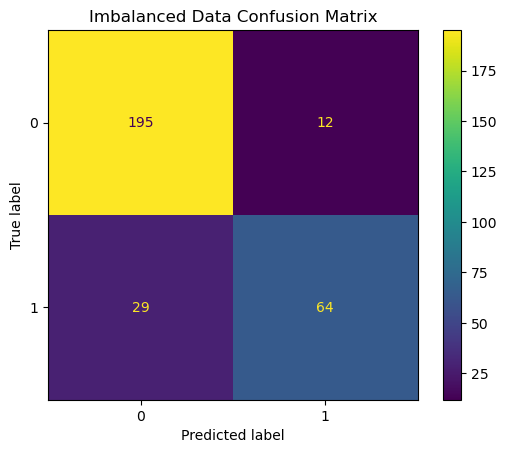

In [18]:
import matplotlib.pyplot as plt
cm_display.plot()
plt.title('Imbalanced Data Confusion Matrix')
plt.savefig("Imbalanced Data.png")
plt.show()

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority', random_state=42)
X_S, y_S = smote.fit_resample(X, y)

In [21]:
from collections import Counter
print("Before SMOTE:", Counter(y))
print("After SMOTE:", Counter(y_S))

Before SMOTE: Counter({0: 828, 1: 372})
After SMOTE: Counter({1: 828, 0: 828})


In [25]:
logrS = linear_model.LogisticRegression()
logrS.fit(X_S,y_S)
yhatS = logrS.predict(test.drop(columns = 'HiringDecision'))

C:\Users\mpkhd\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


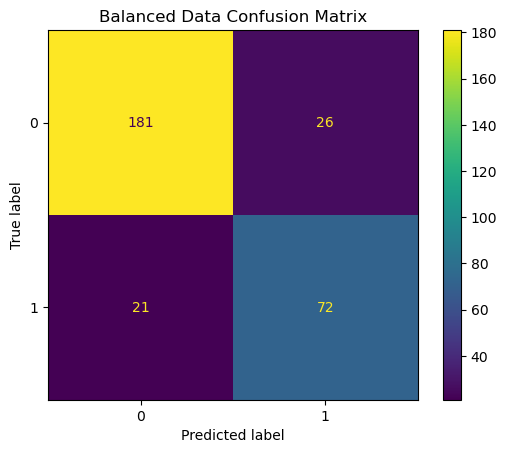

In [27]:
confusion_matrix = metrics.confusion_matrix(test['HiringDecision'], yhatS)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.title('Balanced Data Confusion Matrix')
plt.savefig("Balanced Data.png")
plt.show()

In [52]:
from imblearn.combine import SMOTETomek
smote_tomek = SMOTETomek(random_state=42)
X_res, y_res = smote_tomek.fit_resample(X, y)

In [44]:
logrST = linear_model.LogisticRegression()
logrST.fit(X_res,y_res)
yhatST = logrS.predict(test.drop(columns = 'HiringDecision'))

C:\Users\mpkhd\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


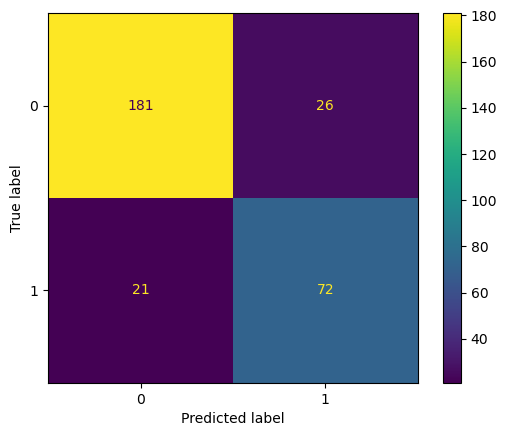

In [46]:
confusion_matrix = metrics.confusion_matrix(test['HiringDecision'], yhatST)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

In [50]:
from imblearn.combine import SMOTEENN
smote_enn = SMOTEENN(random_state=42)
X_SE, y_SE = smote_enn.fit_resample(X, y)

In [54]:
logrSE = linear_model.LogisticRegression()
logrSE.fit(X_SE,y_SE)
yhatSE = logrS.predict(test.drop(columns = 'HiringDecision'))

C:\Users\mpkhd\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


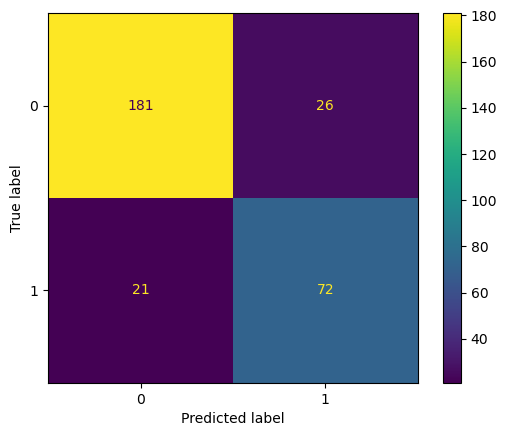

In [58]:
confusion_matrix = metrics.confusion_matrix(test['HiringDecision'], yhatSE)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

In [60]:
from imblearn.over_sampling import ADASYN
adasyn = ADASYN(random_state=42)
X_A, y_A = adasyn.fit_resample(X, y)

In [62]:
logrA = linear_model.LogisticRegression()
logrA.fit(X_A,y_A)
yhatA = logrS.predict(test.drop(columns = 'HiringDecision'))

C:\Users\mpkhd\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


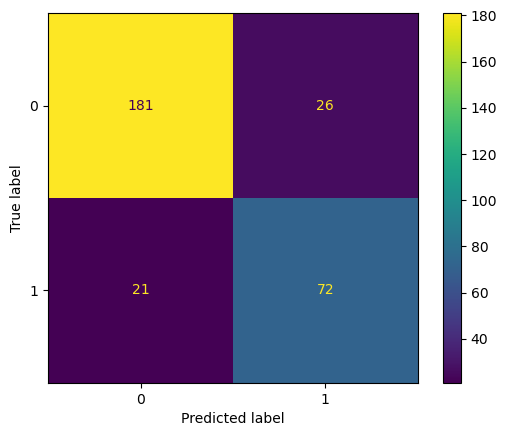

In [64]:
confusion_matrix = metrics.confusion_matrix(test['HiringDecision'], yhatA)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

In [29]:
from sklearn.metrics import classification_report

print(classification_report(test['HiringDecision'], yhat))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90       207
           1       0.84      0.69      0.76        93

    accuracy                           0.86       300
   macro avg       0.86      0.82      0.83       300
weighted avg       0.86      0.86      0.86       300



In [31]:
print(classification_report(test['HiringDecision'], yhatS))

              precision    recall  f1-score   support

           0       0.90      0.87      0.89       207
           1       0.73      0.77      0.75        93

    accuracy                           0.84       300
   macro avg       0.82      0.82      0.82       300
weighted avg       0.85      0.84      0.84       300



In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(test['HiringDecision'], yhat)
prec = precision_score(test['HiringDecision'],yhat, average='weighted')
rec = recall_score(test['HiringDecision'], yhat, average='weighted')
f1 = f1_score(test['HiringDecision'], yhat, average='weighted')

print(f"Accuracy: {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall: {rec:.2f}")
print(f"F1 Score: {f1:.2f}")


Accuracy: 0.86
Precision: 0.86
Recall: 0.86
F1 Score: 0.86


In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(test['HiringDecision'], yhatS)
prec = precision_score(test['HiringDecision'],yhatS, average='weighted')
rec = recall_score(test['HiringDecision'], yhatS, average='weighted')
f1 = f1_score(test['HiringDecision'], yhatS, average='weighted')

print(f"Accuracy: {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall: {rec:.2f}")
print(f"F1 Score: {f1:.2f}")


Accuracy: 0.84
Precision: 0.85
Recall: 0.84
F1 Score: 0.84
